# Lab 02 — VoltLens: classificador por transferência *legível / ilegível / não é medidor*
Bloco profundo (parte B): MobileNetV3-Small pré-treinada + cabeça de 3 classes **exclusivas** (softmax + entropia cruzada).
As fotos do cliente **não** estão no repositório: ajuste `FOTOS_DIR` abaixo.

In [1]:
# ---------- CONFIGURAÇÃO (única célula a editar) ----------
from pathlib import Path
FOTOS_DIR = Path(r"D:/LUCAS/Cesar School/Cadeiras/Deep Learning/fotos_lab02")   # <FOTOS_DIR>/<lote>/<nome_arquivo>.jpg  (FORA do repositório; NÃO versionar)
LOTES = {"treino": ["PSP_EXTRATLEITIMPL_200526_0352", "PSP_EXTRATLEITIMPL_210526_0335"],   # 20/05 + 21/05
         "val":    ["PSP_EXTRATLEITIMPL_220526_0408"],                                    # 22/05
         "teste":  ["PSP_EXTRATLEITIMPL_030726_0121"]}                                    # 03/07
RAIZ = Path.cwd() if (Path.cwd() / "rotulos").exists() else Path("lab-02")
ROTULOS_CSV = RAIZ / "rotulos" / "rotulos.csv"
MAPA_IDS_CSV = RAIZ / "rotulos" / "ids.csv"      # nome_arquivo, id_leitura, numero_medidor (extraído dos CSVs do cliente; também NÃO versionar se identificar cliente)
CLASSES = ["legivel", "ilegivel", "nao_medidor"]
SEMENTES = [0, 1, 2]
ALTURA, LARGURA = 480, 360

In [2]:
import math, time, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision.models import MobileNet_V3_Small_Weights, mobilenet_v3_small
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
torch.set_num_threads(2); torch.manual_seed(42); np.random.seed(42)
MEDIA, DP = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1), torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

## C — Rótulos e partição por lote

In [3]:
df = pd.read_csv(ROTULOS_CSV)
lote_para_conj = {l: c for c, ls in LOTES.items() for l in ls}
df["conjunto"] = df["lote"].astype(str).map(lote_para_conj)
assert df["conjunto"].notna().all(), "lote fora de LOTES: ajuste a configuração"
print(len(df), "fotos rotuladas")
print(pd.crosstab(df["lote"], df["rotulo"], margins=True))
print(pd.crosstab(df["conjunto"], df["rotulo"], margins=True))

300 fotos rotuladas


rotulo                          ilegivel  legivel  nao_medidor  All
lote                                                               
PSP_EXTRATLEITIMPL_030726_0121        30       40            5   75
PSP_EXTRATLEITIMPL_200526_0352        35       37            3   75
PSP_EXTRATLEITIMPL_210526_0335        38       32            5   75
PSP_EXTRATLEITIMPL_220526_0408        37       35            3   75
All                                  140      144           16  300
rotulo    ilegivel  legivel  nao_medidor  All
conjunto                                     
teste           30       40            5   75
treino          73       69            8  150
val             37       35            3   75
All            140      144           16  300


In [4]:
# C4 — prova numérica de ausência de vazamento (partição por lote, nunca por foto)
ids = pd.read_csv(MAPA_IDS_CSV)                      # id_leitura = nome sem sufixo _00N; numero_medidor dos CSVs do cliente
d = df.merge(ids, on="nome_arquivo", how="left")
assert d["id_leitura"].notna().all() and d["numero_medidor"].notna().all(), "ids.csv incompleto"
conj = {c: d[d.conjunto == c] for c in ["treino", "val", "teste"]}
for a, b in [("treino","val"), ("treino","teste"), ("val","teste")]:
    il = set(conj[a].id_leitura) & set(conj[b].id_leitura)
    nm = set(conj[a].numero_medidor) & set(conj[b].numero_medidor)
    print(f"{a:>6} x {b:<6} | leituras em comum: {len(il)} | medidores em comum: {len(nm)}")
    assert not il, "vazamento por leitura"
    if nm: warnings.warn(f"{len(nm)} medidores em comum entre {a} e {b}: remover do conjunto menor")

treino x val    | leituras em comum: 0 | medidores em comum: 0
treino x teste  | leituras em comum: 0 | medidores em comum: 0
   val x teste  | leituras em comum: 0 | medidores em comum: 0


## B — Modelo, tabela de formas e parâmetros

In [5]:
class Classificador(nn.Module):
    def __init__(self, pretreinado=True, p_dropout=0.2):
        super().__init__()
        base = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1 if pretreinado else None)
        self.extrator = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.cabeca = nn.Sequential(nn.Dropout(p_dropout), nn.Linear(576, len(CLASSES)))
    def features(self, x): return self.pool(self.extrator(x)).flatten(1)
    def forward(self, x): return self.cabeca(self.features(x))   # LOGITS: sem softmax aqui

def tabela_de_formas(m, x):
    linhas = []
    hs = [mod.register_forward_hook(lambda _m, _i, o, n=n: linhas.append((n, tuple(o.shape))))
          for n, mod in [(f"extrator.{n}", c) for n, c in m.extrator.named_children()] + [("pool", m.pool), ("cabeca", m.cabeca)]]
    with torch.no_grad(): m.eval()(x)
    for h in hs: h.remove()
    print(f"{'camada':<16}{'saída':>24}")
    for n, s in linhas: print(f"{n:<16}{str(s):>24}")

def contar(m):
    return sum(p.numel() for p in m.parameters()), sum(p.numel() for p in m.parameters() if p.requires_grad)

modelo = Classificador()
tabela_de_formas(modelo, torch.randn(1, 3, ALTURA, LARGURA))
print("ajuste fino  : total %s | treináveis %s" % tuple(f"{v:,}" for v in contar(modelo)))
for p in modelo.extrator.parameters(): p.requires_grad = False
print("extração     : total %s | treináveis %s" % tuple(f"{v:,}" for v in contar(modelo)))

camada                             saída
extrator.0             (1, 16, 240, 180)
extrator.1              (1, 16, 120, 90)
extrator.2               (1, 24, 60, 45)
extrator.3               (1, 24, 60, 45)
extrator.4               (1, 40, 30, 23)
extrator.5               (1, 40, 30, 23)
extrator.6               (1, 40, 30, 23)
extrator.7               (1, 48, 30, 23)
extrator.8               (1, 48, 30, 23)
extrator.9               (1, 96, 15, 12)
extrator.10              (1, 96, 15, 12)
extrator.11              (1, 96, 15, 12)
extrator.12             (1, 576, 15, 12)
pool                      (1, 576, 1, 1)
cabeca                            (1, 3)
ajuste fino  : total 928,739 | treináveis 928,739
extração     : total 928,739 | treináveis 1,731


**B3 — ativação e perda.** As três classes são mutuamente exclusivas (uma foto é uma coisa só), portanto `softmax` + `CrossEntropyLoss`. O modelo devolve *logits*; a softmax só é aplicada na inferência (E). Exemplo real que prova a exclusividade: `PSP_EXTRATLEITIMPL_030726_0121_20000000002303017005_000.jpg` tem uma única classe, `legivel` (consenso; um rotulador a viu como `ilegivel`, mas nenhum a viu como as duas ao mesmo tempo). O mesmo vale para `PSP_EXTRATLEITIMPL_030726_0121_20000000000852982572_000.jpg`, `ilegivel`. Uma foto não pode ser legível e ilegível.

In [6]:
def carregar(nome, lote):
    img = Image.open(FOTOS_DIR / str(lote) / nome).convert("RGB")
    assert img.size == (LARGURA, ALTURA), f"{nome}: {img.size}"
    t = torch.from_numpy(np.asarray(img).copy()).permute(2, 0, 1).float() / 255
    return (t - MEDIA) / DP
def tensores(sub):
    X = torch.stack([carregar(r.nome_arquivo, r.lote) for r in sub.itertuples()])
    y = torch.tensor([CLASSES.index(r) for r in sub.rotulo])
    return X, y
dados = {c: tensores(df[df.conjunto == c].reset_index(drop=True)) for c in ["treino", "val", "teste"]}
print({c: tuple(v[0].shape) for c, v in dados.items()})

{'treino': (150, 3, 480, 360), 'val': (75, 3, 480, 360), 'teste': (75, 3, 480, 360)}


## D — Sanidade

In [7]:
# D1 — perda inicial com pesos aleatórios (cabeça aleatória, extrator pré-treinado) vs ln(3)
m0 = Classificador(); m0.eval()
Xv, yv = dados["val"]
with torch.no_grad(): ce0 = F.cross_entropy(m0(Xv[:32]), yv[:32]).item()
print(f"perda inicial = {ce0:.3f} | ln(3) = {math.log(3):.3f}")

perda inicial = 1.121 | ln(3) = 1.099


In [8]:
# D2 — sobreajustar 16 fotos reais (sem dropout, tudo treinável) até perda ~0
m2 = Classificador(); m2.cabeca[0].p = 0.0
Xt, yt = dados["treino"]; idx = torch.randperm(len(Xt))[:16]
xb, yb = Xt[idx], yt[idx]
opt = torch.optim.Adam(m2.parameters(), lr=1e-3); m2.train()
for i in range(80):
    opt.zero_grad(); l = F.cross_entropy(m2(xb), yb); l.backward(); opt.step()
    if i in (0, 79): print(f"passo {i:>2}: perda = {l.item():.4f}")
assert l.item() < 0.1, "não decorou 16 fotos: diagnosticar rede/perda/rótulos antes de seguir"

passo  0: perda = 1.1567


passo 79: perda = 0.0001


In [9]:
# D3 — extração de características (cabeça treinada sobre extrator congelado) vs baselines, 3 sementes
base = Classificador(); base.eval()
@torch.no_grad()
def feats(X): return torch.cat([base.features(X[i:i+32]) for i in range(0, len(X), 32)])
Ftr, Fva, Fte = (feats(dados[c][0]) for c in ["treino", "val", "teste"])
ytr, yva, yte = (dados[c][1] for c in ["treino", "val", "teste"])

def treina_cabeca(seed, epocas=30, bs=16):
    # a semente muda a inicialização da cabeça E a ordem dos minibatches (com lote cheio e extrator
    # congelado o problema é convexo e todas as sementes dariam o mesmo resultado, desvio = 0)
    g = torch.Generator().manual_seed(seed); torch.manual_seed(seed)
    cab = nn.Linear(576, 3); opt = torch.optim.AdamW(cab.parameters(), lr=1e-3, weight_decay=1e-3)
    peso = (len(ytr) / (3 * torch.bincount(ytr, minlength=3).clamp(min=1))).float()
    for _ in range(epocas):
        for idx in torch.randperm(len(ytr), generator=g).split(bs):
            opt.zero_grad(); F.cross_entropy(cab(Ftr[idx]), ytr[idx], weight=peso).backward(); opt.step()
    return cab

def classico(X):   # baseline não profunda: histograma de cinza (16 bins) + variância do Laplaciano
    out = []
    for x in X:
        g = (x * DP + MEDIA).mean(0).numpy()
        lap = g[1:-1,1:-1]*4 - g[:-2,1:-1] - g[2:,1:-1] - g[1:-1,:-2] - g[1:-1,2:]
        out.append(np.r_[np.histogram(g, 16, (0, 1), density=True)[0], lap.var()])
    return np.array(out)
Ctr, Cva, Cte = (classico(dados[c][0]) for c in ["treino", "val", "teste"])

res = {"profundo (extração)": [], "LR sobre histograma+Laplaciano": []}
for s in SEMENTES:
    cab = treina_cabeca(s)
    with torch.no_grad(): p = cab(Fva).argmax(1).numpy()
    res["profundo (extração)"].append(f1_score(yva, p, average="macro"))
    lr = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=s).fit(Ctr, ytr)
    res["LR sobre histograma+Laplaciano"].append(f1_score(yva, lr.predict(Cva), average="macro"))
print("(a baseline LR é determinística: desvio 0 é esperado)")
print("F1-macro na validação (média ± desvio, 3 sementes):")
for k, v in res.items(): print(f"  {k:<34} {np.mean(v):.3f} ± {np.std(v):.3f}   {np.round(v, 3)}")

(a baseline LR é determinística: desvio 0 é esperado)
F1-macro na validação (média ± desvio, 3 sementes):
  profundo (extração)                0.717 ± 0.001   [0.718 0.717 0.718]
  LR sobre histograma+Laplaciano     0.427 ± 0.000   [0.427 0.427 0.427]


**Leitura (D3).** O bloco profundo não perdeu: F1-macro de validação 0,717 ± 0,001 contra 0,427 da regressão logística sobre histograma + Laplaciano, uma diferença de cerca de 0,29. Esse desempenho vem das *features* da ImageNet com só a cabeça linear treinada (1.731 parâmetros), então a vantagem não depende de ajuste fino. O desvio entre sementes é pequeno porque o extrator é congelado e só a cabeça varia. A baseline clássica mede borrão e brilho globais, mas não enxerga se há dígitos, por isso fica perto de chutar a classe majoritária.

## E — Confiança e recusa (ajustados na **validação**, avaliados no teste)

T = 0.910


ECE validação: antes 0.086 | depois 0.070
ECE teste    : antes 0.108 | depois 0.111


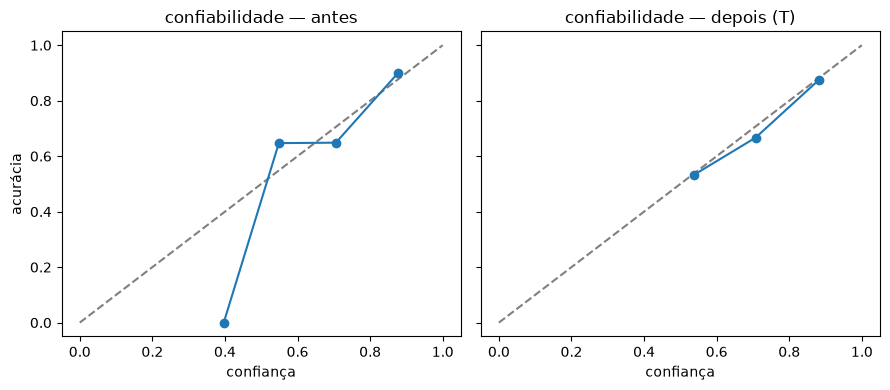

In [10]:
cab = treina_cabeca(0)
with torch.no_grad(): Lva, Lte = cab(Fva), cab(Fte)

def ece(p, y, bins=10):
    conf, pred = p.max(1); acerto = (pred == y).float(); e = 0.0
    for lo in np.linspace(0, 1, bins, endpoint=False):
        m = (conf > lo) & (conf <= lo + 1 / bins)
        if m.any(): e += m.float().mean().item() * abs(acerto[m].mean().item() - conf[m].mean().item())
    return e

T = torch.ones(1, requires_grad=True)
opt = torch.optim.LBFGS([T], lr=0.1, max_iter=100)
def clos():
    opt.zero_grad(); l = F.cross_entropy(Lva / T, yva); l.backward(); return l
opt.step(clos); T = T.item()
print(f"T = {T:.3f}")
print(f"ECE validação: antes {ece(Lva.softmax(1), yva):.3f} | depois {ece((Lva/T).softmax(1), yva):.3f}")
print(f"ECE teste    : antes {ece(Lte.softmax(1), yte):.3f} | depois {ece((Lte/T).softmax(1), yte):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharey=True)
for a, (nome, L) in zip(ax, [("antes", Lva), ("depois (T)", Lva / T)]):
    p = L.softmax(1); conf, pred = p.max(1); ac = (pred == yva).float()
    b = np.linspace(0, 1, 6); xs, ys = [], []
    for lo, hi in zip(b[:-1], b[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any(): xs.append(conf[m].mean().item()); ys.append(ac[m].mean().item())
    a.plot([0, 1], [0, 1], "--", c="gray"); a.plot(xs, ys, "o-"); a.set_title(f"confiabilidade — {nome}"); a.set_xlabel("confiança")
ax[0].set_ylabel("acurácia"); plt.tight_layout(); plt.show()

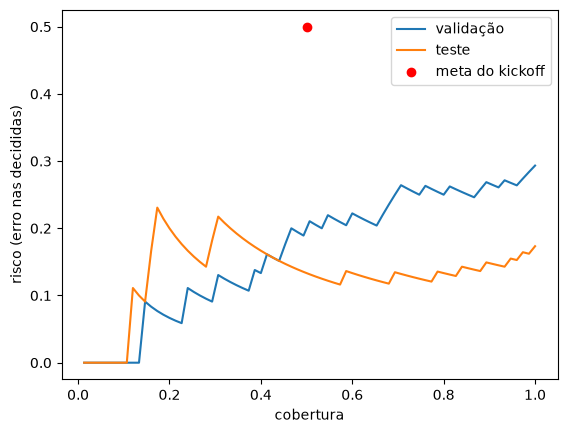

risco em cobertura 50%: validação 0.211 | teste 0.132 | alvo <= 0.5


In [11]:
# E2 — cobertura x risco da decisão "legível" (limiar escolhido na validação; curva também no teste)
def curva(L, y, T):
    p = (L / T).softmax(1); conf, pred = p.max(1); ordem = conf.argsort(descending=True)
    err = (pred[ordem] != y[ordem]).float().cumsum(0) / torch.arange(1, len(y) + 1)
    return (torch.arange(1, len(y) + 1) / len(y)).numpy(), err.numpy()
cv, rv = curva(Lva, yva, T); ct, rt = curva(Lte, yte, T)
COBERTURA_ALVO, RISCO_ALVO = 0.50, 0.50      # meta: cobertura >= 50% com risco <= 50% (X = 50%); ver README V2
plt.plot(cv, rv, label="validação"); plt.plot(ct, rt, label="teste")
plt.scatter([COBERTURA_ALVO], [RISCO_ALVO], c="r", zorder=5, label="meta do kickoff")
plt.xlabel("cobertura"); plt.ylabel("risco (erro nas decididas)"); plt.legend(); plt.show()
i = np.searchsorted(cv, COBERTURA_ALVO)
print(f"risco em cobertura {COBERTURA_ALVO:.0%}: validação {rv[i]:.3f} | teste {rt[min(i, len(rt)-1)]:.3f} | alvo <= {RISCO_ALVO}")

## V — Parte específica (V3, V4)
V3 (pareamento foto ↔ registro, 866 fotos órfãs) e V4 (leituras de valor 0 com foto) são calculados por `ferramentas/v3_v4.py` a partir do zip do cliente, que não fica no repositório; os resultados completos estão no `README.md`. A célula abaixo lê a saída do V4 (classe prevista para as 225 leituras de zero com foto, fora das 300 rotuladas) e resume por classe e por lote.

In [12]:
# V4 — zeros com foto passados pelo classificador (saída de ferramentas/v3_v4.py; não versionada)
ZEROS_CSV = RAIZ / "saidas" / "zeros_predicoes.csv"
if ZEROS_CSV.exists():
    zp = pd.read_csv(ZEROS_CSV)
    print(f"zeros com foto fora das 300 rotuladas: {len(zp)}")
    print(zp.pred.value_counts().reindex(CLASSES, fill_value=0).to_string())
    print(f"legível com confiança >= 0,7: {((zp.pred == 'legivel') & (zp.conf >= 0.7)).sum()}")
    print(pd.crosstab(zp.lote, zp.pred).to_string())
else:
    print("saidas/zeros_predicoes.csv ausente: rode ferramentas/v3_v4.py (precisa do zip do cliente)")

zeros com foto fora das 300 rotuladas: 225
pred
legivel        123
ilegivel        94
nao_medidor      8
legível com confiança >= 0,7: 98


pred                            ilegivel  legivel  nao_medidor
lote                                                          
PSP_EXTRATLEITIMPL_030726_0121        27       33            3
PSP_EXTRATLEITIMPL_200526_0352        28       31            3
PSP_EXTRATLEITIMPL_210526_0335        17       25            1
PSP_EXTRATLEITIMPL_220526_0408        22       34            1


## F — Medidas para a ficha de arquitetura (teste, meta V2 e latência)

In [13]:
# F1 — desempenho no TESTE (03/07), com a cabeça treinada em D3 e T ajustado na validação (E)
from sklearn.metrics import confusion_matrix, classification_report
with torch.no_grad(): pte = (Lte / T).softmax(1)
pred_te = pte.argmax(1).numpy()
print(f"acurácia no teste = {accuracy_score(yte, pred_te):.3f} | F1-macro = {f1_score(yte, pred_te, average='macro'):.3f}")
print("matriz de confusão (linhas = verdade, colunas = previsto):", CLASSES)
print(confusion_matrix(yte, pred_te))
print(classification_report(yte, pred_te, target_names=CLASSES, digits=3, zero_division=0))

acurácia no teste = 0.827 | F1-macro = 0.813
matriz de confusão (linhas = verdade, colunas = previsto): ['legivel', 'ilegivel', 'nao_medidor']
[[37  3  0]
 [ 8 21  1]
 [ 1  0  4]]
              precision    recall  f1-score   support

     legivel      0.804     0.925     0.860        40
    ilegivel      0.875     0.700     0.778        30
 nao_medidor      0.800     0.800     0.800         5

    accuracy                          0.827        75
   macro avg      0.826     0.808     0.813        75
weighted avg      0.832     0.827     0.823        75



In [14]:
# V2 em número: cobertura das LEGÍVEIS x precisão da decisão "legível" (proxy do status Leitura confirmada).
# O limiar tau é escolhido na VALIDAÇÃO e aplicado ao teste.
with torch.no_grad(): pva = (Lva / T).softmax(1)
sva, ste = pva[:, 0].numpy(), pte[:, 0].numpy()
leg_va, leg_te = (yva == 0).numpy(), (yte == 0).numpy()
def op(s, leg, tau):
    dec = s >= tau
    return dec[leg].mean(), (leg[dec].mean() if dec.any() else float("nan")), int(dec.sum())
print(f"{'cobertura alvo':>15} {'tau (val)':>10} | {'val: cob.':>9} {'prec.':>6} | {'teste: cob.':>11} {'prec.':>6} {'decididas':>9}")
for alvo in (0.3, 0.5, 0.7):
    taus = np.sort(sva[leg_va])[::-1]; tau = taus[max(int(np.ceil(alvo * len(taus))) - 1, 0)]   # menor tau com cobertura >= alvo na validação
    cv_, pv_, _ = op(sva, leg_va, tau); ct_, pt_, nt_ = op(ste, leg_te, tau)
    print(f"{alvo:>15.0%} {tau:>10.3f} | {cv_:>9.2f} {pv_:>6.2f} | {ct_:>11.2f} {pt_:>6.2f} {nt_:>9d}")

 cobertura alvo  tau (val) | val: cob.  prec. | teste: cob.  prec. decididas
            30%      0.835 |      0.31   0.92 |        0.55   0.85        26
            50%      0.729 |      0.51   0.82 |        0.65   0.84        31
            70%      0.639 |      0.71   0.76 |        0.72   0.83        35


In [15]:
# Latência do classificador em CPU (1 foto 480x360, modelo completo, 2 threads, após aquecimento)
mlat = Classificador(pretreinado=False).eval(); x1 = torch.randn(1, 3, ALTURA, LARGURA); ts = []
with torch.no_grad():
    for _ in range(10): mlat(x1)
    for _ in range(100):
        t0 = time.perf_counter(); mlat(x1); ts.append((time.perf_counter() - t0) * 1000)
print(f"latência por foto (ms): p50 = {np.percentile(ts, 50):.1f} | p95 = {np.percentile(ts, 95):.1f} | threads = {torch.get_num_threads()}")
print(f"throughput estimado: {1000 / np.percentile(ts, 50):.1f} fotos/s -> {3100 * np.percentile(ts, 50) / 60000:.1f} min para 3.100 fotos")

latência por foto (ms): p50 = 15.3 | p95 = 20.6 | threads = 2
throughput estimado: 65.5 fotos/s -> 0.8 min para 3.100 fotos
